# Building a temporal theory

Declare a temporal theory for the MSR-JD pipeline and compute its correlators. Sections: the
`dd` toolkit, the action (§1), the components (§2), the graphical builder (§3) and Python
builder (§4), running a theory (§5), worked examples (§6 Langevin SDE, §7 Hawkes process), your
own theory (§8), syntax reference (§9).

Temporal theories only (no spatial extent). No simulation — mean field, cumulants, and loop
corrections are computed analytically.

## 0. Setup

This notebook requires the **SageMath** kernel (the pipeline is built on Sage). If a cell
errors on `import`, check the kernel selector — it should read *SageMath*, not a plain
Python 3. The cell below puts the repository on the path and imports the builder and the
`daedalus` front-end; it is the same setup used by `theory_runner.ipynb`.

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# Locate the repo root (walk up until the 'api' package appears) and add it to the path.
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'api')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))

import daedalus as dd    # one entry point: dd.TemporalTheoryBuilder, dd.run, dd.plot_cumulant, ...
print('daedalus →', dd.REPO_ROOT)

daedalus → /Users/matthewszuromi/Documents/Education/BU PhD/Ocker Lab/Automated Feynman Calculations


## The `dd` toolkit

`daedalus`, imported as `dd`, is the single entry point: it re-exports the pipeline's
user-facing API next to its own notebook helpers. Grouped by purpose:

| purpose | what you call |
|---|---|
| author a theory in code | `dd.TemporalTheoryBuilder` (also `dd.SpatialTheoryBuilder`) |
| author a theory by form | `dd.TheoryUI` — the graphical builder (§3) |
| load / list saved theories | `dd.load_theory(name)`, `dd.list_theories()` |
| inspect a model | `dd.describe_model(model)`, `dd.field_names(model)` |
| configure + run | `dd.Config(...)`, `dd.run(model, cfg, module)` |
| inspect results | `dd.summary(res)`, `dd.plot_cumulant(res, cfg, model)` |
| visualize the diagrams | `dd.plot_prediagrams(model, k, max_ell)`, `dd.prediagram_mappings(model, k, max_ell)` |
| save results | `dd.save_npz`, `dd.save_csv` |
| advanced | `dd.compute_cumulants` (what `run` wraps), `dd.precompute`, `dd.config_options()` |

§1–§4 cover the theory and how to author it; §5 covers running it; §6–§7 are worked examples.

## 1. The action

A theory is one expression: the MSR-JD action $S$, a functional of the physical fields and an
equal number of response fields. The pipeline derives the propagators, vertices, mean field,
and cumulants from it. Form:

$$S \;=\; \sum_{\text{fields}}(\text{response field})\times(\text{equation of motion}) \;+\; (\text{source terms}).$$

Build $S$ from the pieces below; the right column is what goes in `set_action_text` (§2.8).
Field `x` has response field `xt`.

| piece | equation | action term |
|---|---|---|
| drift / relaxation | $\dot x = -\mu x - \varepsilon x^3$ | `xt*((Dt+mu)*x + eps*x^3)` |
| white Gaussian noise | $\langle\xi\xi\rangle = 2D\delta$ | `- D*xt^2` |
| point-process spikes | $n \sim \mathrm{Poisson}[\varphi(v)]$ | `nt*n - (exp(nt)-1)*phi(v)` |
| memory / synaptic kernel | $\tau\dot v = -(v-E) + w\,(g*n)$ | `vt*((tau*Dt+1)*v - E - w*Conv(g,n))` |
| cross-correlated noise | $\langle\xi_a\xi_b\rangle = \rho\sqrt{D_aD_b}\,\delta$ | `- 2*rho*sqrt(Da*Db)*at*bt` |

Multi-population models replicate fields over an index $i$ and sum the action `for i in pop`.
§6 assembles the first two rows; §7 assembles rows 1–4.

## 2. The components of a temporal theory

The ten ingredients below are the tabs of the graphical builder (§3) and the methods of the
Python builder (§4). *Model*, *Fields*, *Parameters*, *Action*, and *Mean-field* are required;
the rest are used as needed.

### 2.1 Model
A name (and optional description). On save it becomes the `.theory.py` filename.
Python: the constructor argument, `dd.TemporalTheoryBuilder('My model')`.

### 2.2 Populations *(optional)*
A **population** is a set of units sharing the same dynamics — $N$ neurons, $N$
spins. Declared with a name and size; thereafter fields and parameters carry an index `[i]`
and the action sums `for i in pop`. Omit it for a single scalar variable. It also lets you write the action more concisely.
Python: `.population('E', size=4)`.

### 2.3 Fields
The physical variables. Declaring a field `x`
**automatically** creates two companions used in model construction:

| symbol | role | where it appears |
|---|---|---|
| `x` | the field | the equation of motion, the mean-field equations |
| `xt` | its MSR **response** field | the response×EOM term and the source terms |
| `xstar` | the **saddle** (steady state) | solved for by the mean-field equations |

Python: `.physical_field('x', population='E')` (drop `population` for a scalar). Internally the
*fluctuation* about the saddle is named `dx` — that prefixed name is what you put on a
correlator leg (§2.10).

### 2.4 Parameters
Numerical constants — rates, couplings, time constants, noise amplitudes. Shape is set by how
many population indices they carry, if populations are declared:

| `indexed_by` | shape | written as | `default` |
|---|---|---|---|
| `None` | scalar | `mu` | `1.0` |
| `['E']` | vector $N_E$ | `mu[i]` | `[1.0, 2.0]` |
| `['E','E']` | matrix $N_E\times N_E$ | `w[i,j]` | `[[1,0.5],[0.5,1]]` |

`domain='positive'` / `'real'` sets the parameter's domain (e.g. a timescale is always positive). The more restrictive the domain, the faster the pipeline's symbolic computation.
Python:
`.parameter('mu', default=1.0, domain='positive', indexed_by=['E'])`.

### 2.5 Functions of physical fields *(optional)*
A named function abbreviates an expression you reuse in the action, keeping it compact. It can be
polynomial (e.g. `a*v^2`) or non-polynomial (`tanh`, `exp`, a transfer function) — either is fine;
the point is to write a repeated term once. Functions are naturally indexable over populations. Python:
`.define_function('phi', args=['v'], expression='a[i]*v^2', population='E')`, then call it in
the action as `phi[i](v[i])`.

### 2.6 Convolutional Kernels *(optional)*
Temporal **convolutions** — synaptic filters, memory, colored noise. A kernel $g(t)$ couples a
field to a time-filtered version of another. To keep the mean-field equations and symbolic work simple, kernels are required to integrate to 1. Give it as a time expression (use `heaviside(t)`
for causality) and/or its Fourier image. Pulse coupling is expressed either by omitting the kernel or by setting it to `dirac_delta(t)`. Python:
`.define_kernel('g', time_expr='(1/taug)*exp(-t/taug)*heaviside(t)', freq_image='1/(1+I*omega*taug)', indexed_by=['E','E'])`,
then in the action `Conv(g[i,j], n[j])` (or `g[i,j]*n[j]`).

### 2.7 Noise / source terms *(optional)*
The stochastic drive. White Gaussian ($\langle\xi\xi\rangle = 2D\delta$, term `- D*xt^2`) and
point-process ($n\sim\mathrm{Poisson}[\varphi]$, term `- (exp(nt)-1)*phi(v)`) drives go straight in
the action — see the §1 table. The remaining source types:

| source | how to add it |
|---|---|
| cross-correlated noise between fields $a,b$ | `- 2*rho*sqrt(Da*Db)*at*bt` (in the action) |
| non-Gaussian: a higher cumulant (e.g. 3rd) | `- S3*xt^3` (adds $\kappa^{(3)} = 3!\,S3$; in the action) |
| colored — **Gaussian only**, finite $\tau_c$ | OU kernel `exp(-abs(tau)/tauc)` — Noise tab |
| GTaS external drive (Bernoulli + Gaussian shared input) | Noise tab — `.add_gtas_noise(dd.GTaSNoise(...))` |

Colored noise is supported only for **Gaussian** forcing, via the OU / single-exponential kernel
$\exp(-|\tau|/\tau_c)$ (Markovian-embeddable). A higher white cumulant is just the action monomial
above; cross-field colored noise and GTaS are declared on the builder's Noise tab.

**Noise declared on that tab is added to the action automatically — do not also write it in the action by hand.**

### 2.8 The action
The MSR–JD action itself — the assembly of §2.1–2.7 into one expression of the form
*response × equation-of-motion + sources*. Syntax:

- physical field `x[i]`, response `xt[i]`; index `[i]` ranges over the population
- `Dt` is $\partial_t$: write `(Dt + mu)*x[i]`, `(tau[i]*Dt + 1)*v[i]`
- `^` is a power: `x[i]^3`
- `sum( expr for i in E )` sums over a population; inner sums `sum(w[i,j]*n[j] for j in E)`
- transfer functions `phi[i](v[i])`; convolutions `Conv(g[i,j], n[j])`
- write the action in terms of the original **physical** fields — the pipeline does the saddle + fluctuation split itself; do
  not write `xstar + dx` by hand

### 2.9 Mean-field equations
The deterministic equations whose steady state gives the saddle `xstar` the diagrams expand
around. One per field. `Dt` may appear; the solver sets `Dt → 0` and runs multi-start Newton. It can also run a linear-stability analysis and expand only around stable roots.
Python: `.equation(lhs='(Dt+mu)*x[i]', rhs='-eps*x[i]^3', population='E')`, or for an algebraic
self-consistency, `.set_mf_equation('nstar', 'phi[i](vstar[i])')`. For multiple roots
(bistability) the solver sorts them and `fixed_point_index` picks one.

NOTE: stability is assessed for the mean-field equations only — loop corrections can shift it, and noise can still drive transitions between wells.

### 2.10 Run settings
Not part of the theory, but how you query it: the correlator order `k` (2 = two-point), the
loop order `max_ell` (0 = tree, 1 = +1-loop, …), the time-lag grid, and the **external legs** —
which fluctuation fields sit on the correlator. A leg names the `d`-prefixed field, e.g.
`[('dx', 1), ('dx', 1)]` for $\langle x\,x\rangle$; leave it `None` to default to the
auto-correlator of the first field.

NOTE: these are defaults only; you can usually skip this tab.

## 3. Graphical builder

[`theory_builder.ipynb`](theory_builder.ipynb) is a form whose tabs are the §2 components
(*Model · Populations · Fields · Parameters · Functions · Kernels · Noise · Action · MF ·
Defaults*); a sidebar flags undeclared names and syntax errors. Launch it here:

In [2]:
ui = dd.TheoryUI()
ui.show()      # fill the tabs, then 'Save theory file' → theories/<name>.theory.py

**Save** writes `theories/<name>.theory.py` (the file name comes from the Model tab).
**Load** reopens any saved theory — the form's *Load theory file* dropdown repopulates every
tab for editing, and the round-trip preserves everything. To *run* a saved theory (here or in
[`theory_runner.ipynb`](theory_runner.ipynb)), load it by name:

```python
model, mod = dd.load_theory('<name>')        # the file name, minus '.theory.py'
res = dd.run(model, dd.Config(k=2, max_ell=0), mod)
```

## 4. Python builder

Each §2 component is one chained method; `.build()` returns the `model`:

```python
model = (
    dd.TemporalTheoryBuilder('name')   # 2.1 Model
    .population(...)                   # 2.2 Populations   (optional)
    .physical_field(...)              # 2.3 Fields
    .parameter(...)                   # 2.4 Parameters
    .define_function(...)             # 2.5 Transfer functions (optional)
    .define_kernel(...)               # 2.6 Kernels        (optional)
    .set_action_text('...')           # 2.7-2.8 Sources + action
    .equation(...) / .set_mf_equation(...)   # 2.9 Mean field
    .build()
)
```

## 5. Running a theory: `Config`, `run`, and plotting

With a `model` in hand (from §3, §4, or `dd.load_theory`), a run is three calls.

**`dd.run(model, cfg, module)`** resolves `cfg` against the theory's defaults, solves the mean
field, enumerates the Feynman diagrams, integrates them, and returns a result dict. `module` is
the loaded theory module for a saved theory, or `None` for an inline-built `model`.

**`dd.Config(...)`** is the run specification. The temporal arguments (leave any `None` to
inherit the theory's `METADATA`; `dd.config_options()` prints them all):

| argument | what it does |
|---|---|
| `k` | correlator order — `2` = two-point $\langle\cdot\,\cdot\rangle$, `3` = three-point, … |
| `max_ell` | loop order — `0` = tree (mean-field level), `1` = +1-loop, … (cost rises fast) |
| `external_fields` | the `k` legs, as `d`-prefixed fluctuation fields, e.g. `[('dx',1),('dx',1)]`; `None` → auto-correlator of the first field |
| `tau_max`, `tau_step` | the symmetric time-lag grid $-\tau_{\max}\dots\tau_{\max}$ for $C(\tau)$ |
| `tau_grid` | an explicit τ grid (array or `(lo,hi,n)`); overrides `tau_max`/`tau_step` |
| `parameters` | numeric overrides `{name: value}` (otherwise the builder defaults) |
| `output` | `'cumulant'` (default; connected) / `'moment'` / `'central_moment'` |
| `fixed_point_index` | which mean-field root to expand around (multi-root / bistable theories) |
| `show_orders` | plot mode — `'cumulative'` (default) / `'incremental'` / `'total'` |
| `logy`, `verbose` | log-scale the plot; print pipeline stage progress |

**`dd.summary(res)`** prints a compact summary (theory, `k`, `max_ell`, fields, mean field).
**`dd.plot_cumulant(res, cfg, model)`** auto-dispatches on the theory — for temporal `k=2` it
draws $C(\tau)$, overlaying each loop order per `show_orders`. (Its `sim=` argument overlays an
external simulation; the `examples/` notebooks use it.) The result dict also exposes the raw
arrays — `res['C_tau']` (the correlator), `res['mf']` (the saddle), and `res['_resolved']` (the
resolved config + parameters).

§6 and §7 apply this end to end.

## 6. Example — Langevin SDE

Model: $\dot x = -\mu x - \varepsilon x^{3} + \xi$, $\langle\xi\xi\rangle = 2D\delta$.
Action: `xt*((Dt+mu)*x + eps*x^3) - D*xt^2`.

In [3]:
ou = (
    dd.TemporalTheoryBuilder('Quartic OU process')
    .physical_field('x',                                   # 2.3  field x (+ response xt, saddle xstar)
                    description='the state variable')
    .parameter('mu',  default=1.0,  domain='positive')     # 2.4  relaxation rate
    .parameter('eps', default=0.05, domain='positive')     # 2.4  cubic nonlinearity
    .parameter('D',   default=1.0,  domain='positive')     # 2.4  noise strength  <xi xi> = 2 D delta
    .set_action_text(                                      # 2.8  response x EOM  +  Gaussian source
        'xt*((Dt+mu)*x + eps*x^3) - D*xt^2')
    .equation(lhs='(Dt+mu)*x', rhs='-eps*x^3')             # 2.9  deterministic EOM
    .build()
)
dd.describe_model(ou);

────────────────────────────────────────────────────────────────────────
  Quartic OU process
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — the state variable
Response fields: xt
Parameters     :
    mu = 1.00000000000000  (positive)
    eps = 0.0500000000000000  (positive)
    D = 1.00000000000000  (positive)
Mean-field saddle (solved by the pipeline): xstar
Governing eqn  : (Dt+mu)*x = -eps*x^3
Action  S      : xt*((Dt+mu)*x + eps*x^3) - D*xt^2


Run and plot $C(\tau)$:

theory : 'Quartic OU process'
k      : 2    max_ell : 0
fields : ['x']   spatial_dim : 0


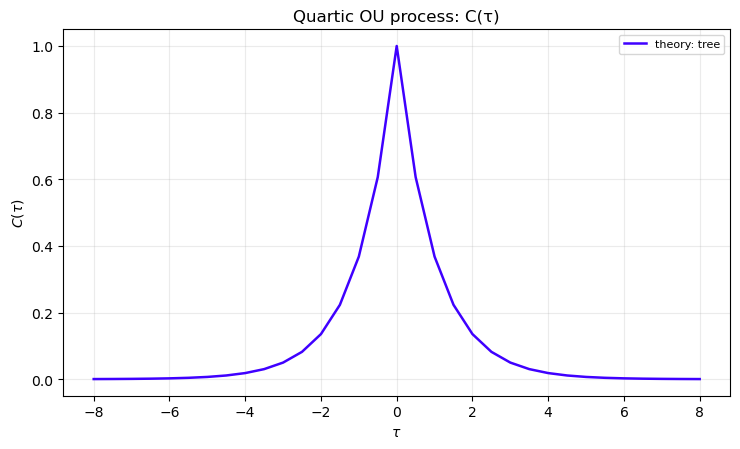

In [4]:
ou_cfg = dd.Config(
    k=2,                                      # two-point correlator <x x>
    max_ell=0,                                # tree level; raise to 1 for the 1-loop correction
    external_fields=[('dx', 1), ('dx', 1)],    # explicit <x x> legs (fluctuation field dx, pop 1)
    tau_grid=(-8.0, 8.0, 33),
)
ou_res = dd.run(ou, ou_cfg, None)             # mod=None: an inline-built model needs no theory file
print(dd.summary(ou_res))

fig = dd.plot_cumulant(ou_res, ou_cfg, ou)
plt.show()

### Which diagrams contribute — `plot_prediagrams` / `prediagram_mappings`

Before integrating anything, the pipeline fixes the set of **prediagrams**: the MSR-JD
topologies that survive the theory's vertex/source filter for a given `k` and loop order.
Two `dd` helpers expose them for any model (a model dict or a theory name), independent of a run:

- **`dd.plot_prediagrams(model, k, max_ell)`** draws the contributing prediagrams, grouped by
  topology — time flows right→left (sources on the right, interaction vertices in the middle,
  external legs on the left), with generic labels (source *i*, vertex *a*, leg *1*). Layout uses
  graphviz `dot` if installed, else a built-in fallback. Returns the figure; practical range
  `k + max_ell ≤ 4`.
- **`dd.prediagram_mappings(model, k, max_ell)`** prints the companion label-map tables: for each
  prediagram, how the generic labels become actual types (noise cumulant `K⁽ⁿ⁾`, the φ-vertex
  coefficient, the bare propagator, the external field). Returns `(result, text)`.

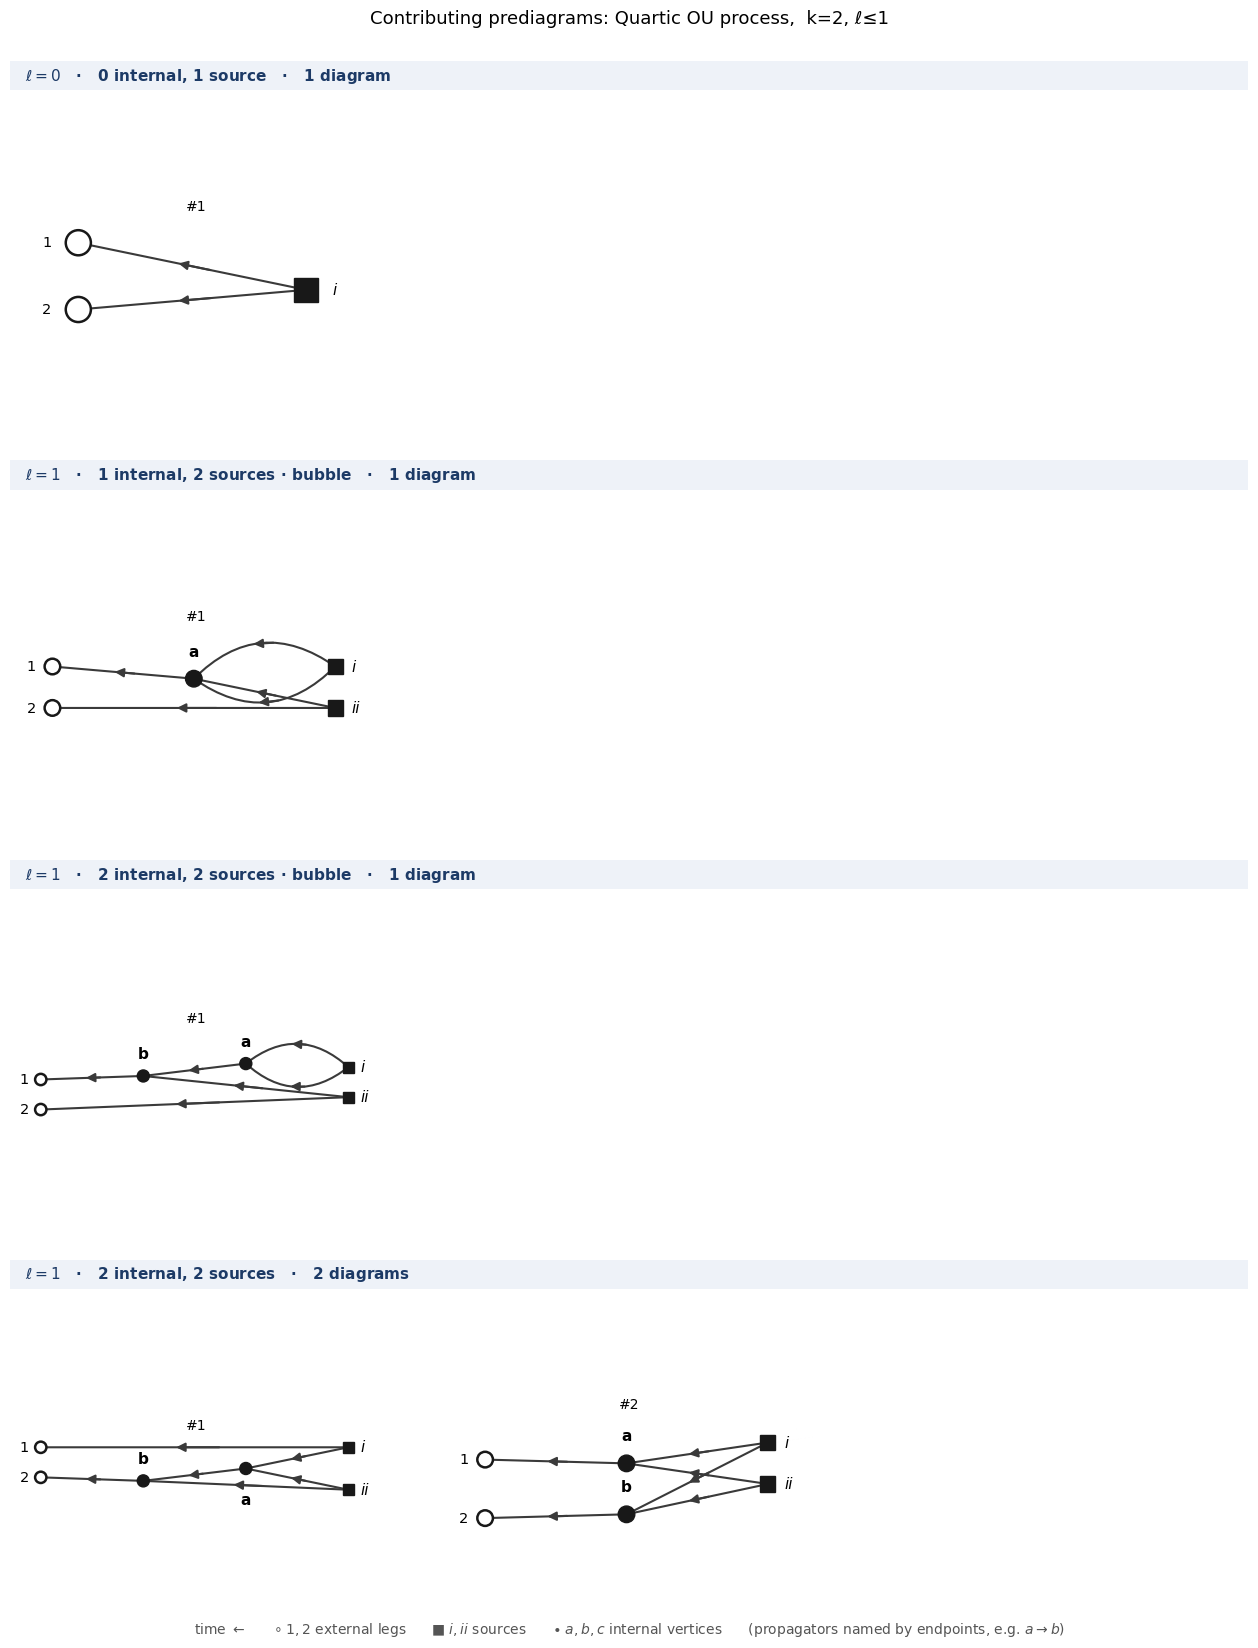

In [5]:
dd.plot_prediagrams(ou, k=2, max_ell=1)

In [6]:
_ = dd.prediagram_mappings(ou, k=2, max_ell=1)

════════════════════════════════════════════════════════════════════════
 Quartic OU process — prediagram → typed-diagram label maps  (k=2, ℓ≤1)
════════════════════════════════════════════════════════════════════════

ℓ=0 · 0 internal, 1 source · #1   (1 typing)
  ── typing 1 ──
     source i    → K^(2) ⟨xt xt⟩
     propagator i→1     → G[dx ← xt]
     propagator i→2     → G[dx ← xt]
     external legs → 1=dx, 2=dx

ℓ=1 · 1 internal, 2 sources · bubble · #1   (1 typing)
  ── typing 1 ──
     source i    → K^(2) ⟨xt xt⟩
     source ii   → K^(2) ⟨xt xt⟩
     vertex a    → coeff eps   resp⟨xt⟩ phys⟨dx dx dx⟩
     propagator a→1     → G[dx ← xt]
     propagator ii→2    → G[dx ← xt]
     propagator ii→a    → G[dx ← xt]
     propagator i→a₁    → G[dx ← xt]
     propagator i→a₂    → G[dx ← xt]
     external legs → 1=dx, 2=dx

ℓ=1 · 2 internal, 2 sources · bubble · #1   (1 typing)
  ── typing 1 ──
     source i    → K^(2) ⟨xt xt⟩
     source ii   → K^(2) ⟨xt xt⟩
     vertex a    → coeff 3*eps

### Saving the result — `save_npz`

`dd.save_npz(result, path)` serializes a run to a `.npz` — `tau_grid`, `C_tau` (with the
per-loop-order breakdown), the mean-field saddle, and the resolved config. The parent directory
is created if missing, and `extra={...}` colocates sidecar arrays (e.g. simulation data).
`dd.save_csv` is the CSV analogue.

In [7]:
print(dd.save_npz(ou_res, 'saved_results/ou_quartic_k2.npz'))

saved_results/ou_quartic_k2.npz


## 7. Example — Hawkes process

Two units; spike train $n_i$ at rate $\varphi(v_i)=a_i v_i^2$; voltage $v_i$ integrating
incoming spikes through instantaneous (delta-coupled) synapses:

$$\tau_i\,\dot v_i = -(v_i - E_i) + \textstyle\sum_j w_{ij}\,n_j, \qquad n_i \sim \mathrm{Poisson}[\varphi(v_i)].$$

Uses a population (2.2), two fields (2.3), vector + matrix parameters (2.4), a transfer
function (2.5), a point-process source (2.7), and algebraic mean-field equations (2.9).

In [8]:
hawkes = (
    dd.TemporalTheoryBuilder('Quadratic Hawkes (delta-coupled)')
    .population('E', size=2, description='excitatory units')                    # 2.2
    .physical_field('n', population='E', description='spike train')             # 2.3
    .physical_field('v', population='E', description='synaptic voltage')        # 2.3
    .parameter('Em',  default=[0.8, 0.78],        indexed_by=['E'],      domain='positive')   # 2.4 vector
    .parameter('tau', default=[10, 9],            indexed_by=['E'],      domain='positive')
    .parameter('a',   default=[0.44, 0.44],       indexed_by=['E'],      domain='positive')
    .parameter('w',   default=[[0.25, 0.25], [0.2, 0.3]], indexed_by=['E', 'E'], domain='positive')  # 2.4 matrix coupling
    .define_function('phi', args=['v'], expression='a[i]*v^2', population='E')  # 2.5 firing-rate curve
    # 2.8 action: spike source  nt*n - (exp(nt)-1)*phi(v)  +  voltage EOM with instantaneous (delta) synapses
    .set_action_text('''
        sum( nt[i]*n[i] - (exp(nt[i])-1)*phi[i](v[i])
        + vt[i]*((tau[i]*Dt + 1)*v[i] - Em[i]
        - sum(w[i,j]*n[j] for j in E))
        for i in E)''')
    .set_mf_equation('vstar', '(Em[i] + sum(w[i,j]*nstar[j] for j in E))')   # 2.9 algebraic MF
    .set_mf_equation('nstar', 'phi[i](vstar[i])')
    .build()
)
dd.describe_model(hawkes);

────────────────────────────────────────────────────────────────────────
  Quadratic Hawkes (delta-coupled)
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : n[E] — spike train; v[E] — synaptic voltage
Response fields: nt, vt
Populations    : E (size 2) — excitatory units
Parameters     :
    Em [E] = [0.800000000000000, 0.780000000000000]  (positive)
    tau [E] = [10, 9]  (positive)
    a [E] = [0.440000000000000, 0.440000000000000]  (positive)
    w [E,E] = [[0.250000000000000, 0.250000000000000], [0.2000000…  (positive)
Mean-field saddle (solved by the pipeline): nstar, vstar
Function       : phi(·) — 1-arg transfer
Action  S      : sum( nt[i]*n[i] - (exp(nt[i])-1)*phi[i](v[i])
                         + vt[i]*((tau[i]*Dt + 1)*v[i] - Em[i]
                         - sum(w[i,j]*n[j] for j in E))
                         for i in E)


Spike-train auto-correlator $C_{nn}(\tau)$ (legs on the `n`-fluctuation, `dn`):

theory : 'Quadratic Hawkes (delta-coupled)'
k      : 2    max_ell : 0
fields : ['n', 'v']   spatial_dim : 0


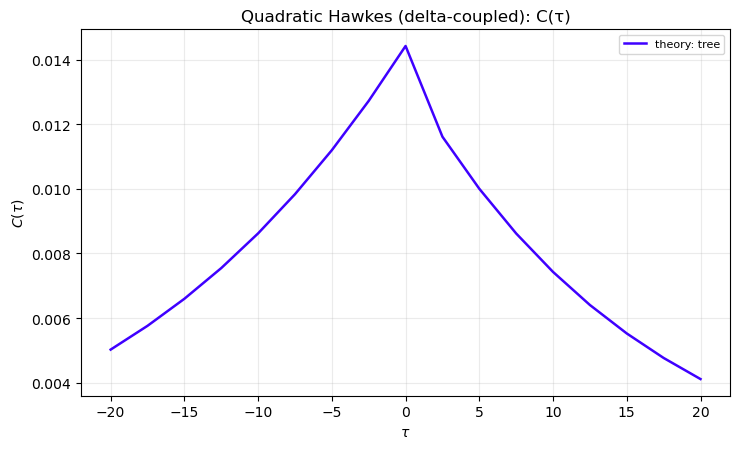

In [9]:
hawkes_cfg = dd.Config(
    k=2, max_ell=0,
    external_fields=[('dn', 1), ('dn', 2)],   # spike-train (n) auto-correlator
    tau_grid=(-20.0, 20.0, 17),
)
hawkes_res = dd.run(hawkes, hawkes_cfg, None)
print(dd.summary(hawkes_res))

fig = dd.plot_cumulant(hawkes_res, hawkes_cfg, hawkes)
plt.show()

## 8. Your own theory

Edit the cell below (starts as the §6 OU); for a point-process or multi-population model, copy
the §7 chain instead.

- a field's action drift term is minus its `equation` / `set_mf_equation` right-hand side —
  keep them consistent;
- `max_ell=0` is tree level; raise for loop corrections;
- `external_fields=None` gives the first field's auto-correlator; name the legs for a
  cross-correlator.

In [10]:
my_model = (
    dd.TemporalTheoryBuilder('My Theory')                  # EDIT: name it
    .physical_field('x',                                   # EDIT: your field(s)
                    description='the state variable')
    .parameter('mu',  default=1.0,  domain='positive')     # EDIT: your parameters
    .parameter('eps', default=0.05, domain='positive')
    .parameter('D',   default=1.0,  domain='positive')
    .set_action_text(                                      # EDIT: your action (response x EOM + source)
        'xt*((Dt+mu)*x + eps*x^3) - D*xt^2')
    .equation(lhs='(Dt+mu)*x', rhs='-eps*x^3')             # EDIT: keep consistent with the action
    .build()
)
# Multiple coupled units? Add .population('E', size=N), index fields/params with [i],
# and sum the action `for i in E` — see the Hawkes example (§7).
dd.describe_model(my_model);

────────────────────────────────────────────────────────────────────────
  My Theory
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — the state variable
Response fields: xt
Parameters     :
    mu = 1.00000000000000  (positive)
    eps = 0.0500000000000000  (positive)
    D = 1.00000000000000  (positive)
Mean-field saddle (solved by the pipeline): xstar
Governing eqn  : (Dt+mu)*x = -eps*x^3
Action  S      : xt*((Dt+mu)*x + eps*x^3) - D*xt^2


Configure and run your theory:

theory : 'My Theory'
k      : 2    max_ell : 0
fields : ['x']   spatial_dim : 0


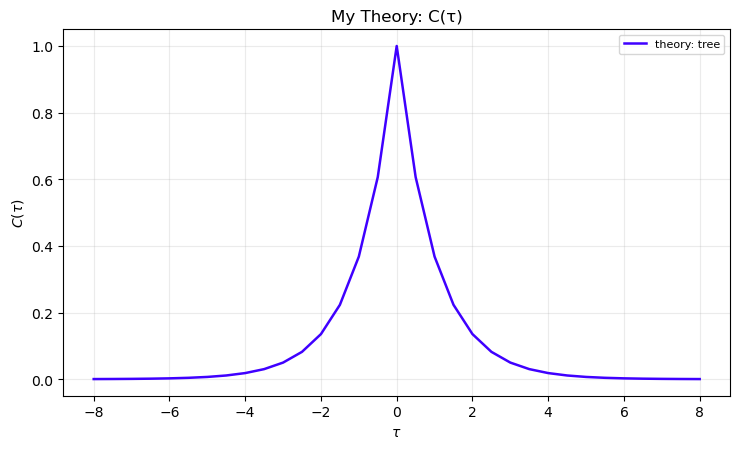

In [11]:
my_cfg = dd.Config(
    k=2, max_ell=0,
    external_fields=[('dx', 1), ('dx', 1)],    # explicit legs: the dx auto-correlator (single field, pop 1)
    tau_grid=(-8.0, 8.0, 33),
)
my_res = dd.run(my_model, my_cfg, None)
print(dd.summary(my_res))

fig = dd.plot_cumulant(my_res, my_cfg, my_model)
plt.show()

## 9. Reference

**Action syntax**

| token | meaning |
|---|---|
| `Dt` | time derivative $\partial_t$ |
| `^` | power, e.g. `x[i]^3` |
| `x[i]`, `xt[i]` | a field and its response partner at index `i` |
| `sum(expr for i in E)` | sum over a population (omit for a scalar) |
| `phi[i](v[i])` | a declared transfer function |
| `Conv(g[i,j], n[j])`, `g[i,j]*n[j]` | a kernel convolution |

**Source-term forms**

| noise | term in the action |
|---|---|
| white Gaussian $\langle\xi\xi\rangle=2D\delta$ | `- D*xt^2` |
| point process at rate $\varphi$ | `- (exp(nt)-1)*phi(v)` |
| cross-correlated $a,b$ | `- 2*rho*sqrt(Da*Db)*at*bt` |
| non-Gaussian, 3rd cumulant | `- S3*xt^3`  ($\kappa^{(3)}=3!\,S3$) |

Colored (Gaussian-only, OU kernel) and GTaS noise are declared on the builder's Noise tab.

**Gotchas**

- No `Conv(...)` in mean-field equations — the stationary saddle has already collapsed
  convolutions of constants; put kernels only in the action.
- `max_ell >= 1` with colored noise is slow (an extra $\tau$-integral per diagram).
- For a bistable theory, enable the stability filter (MF tab / `stability_analysis(True)`) so
  the expansion sits at a linearly stable saddle.
- A purely Gaussian theory needs only the order-2 noise term; non-Gaussian noise needs its
  higher cumulants declared explicitly (Noise tab).

**Where to go next**

- [`theory_builder.ipynb`](theory_builder.ipynb) — the graphical form (§3), with a live
  error-checking sidebar and a pre-compute button.
- [`theory_runner.ipynb`](theory_runner.ipynb) — load any saved `theories/*.theory.py` by name
  and run it with one `dd.Config`.
- [`examples/`](examples/) — one notebook per pipeline capability (these *do* include
  simulation overlays for validation).

**Saving an inline theory as a reusable file.** Wrap the builder chain in a `build()` function
in `theories/<name>.theory.py`, and add module-level `DEFAULT_FUNDAMENTAL = {...}` (numeric
defaults) and `METADATA = {...}` (`k_default`, `tau_max`, `recommended_external_fields`, …).
In a file, import the builder directly — `from api.theory import TemporalTheoryBuilder` —
since `dd` is a notebook helper, not importable from a standalone module. Copy the structure of
any file in `theories/` — `ou_quartic.theory.py` is §6, `quadratic_hawkes_alpha.theory.py` is §7.
It then loads by name in the runner.